In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
def convolve(ax_array, ay_array, bx_array, by_array, mode='subtract'):
    res = []
    amps = []
    for i,ax in enumerate(ax_array):
        for j,bx in enumerate(bx_array):
            if mode == 'subtract':
                res.append(bx - ax)
            elif mode == 'add':
                res.append(bx + ax)
            else:
                raise ValueError("Unsupported mode. Use 'subtract' or 'add'.")
            amps.append(ay_array[i] * by_array[j])

    result = {}
    for val, b_val in zip(res, amps):
        if val not in result:
            result[val] = 0
        result[val] += b_val

    x, y = [], []
    for key, total in result.items():
        x.append(key)
        y.append(total)
    sorted_y = [val for _, val in sorted(zip(x, y), key=lambda pair: pair[0])]
    sorted_x = sorted(x)
    return sorted_x, sorted_y

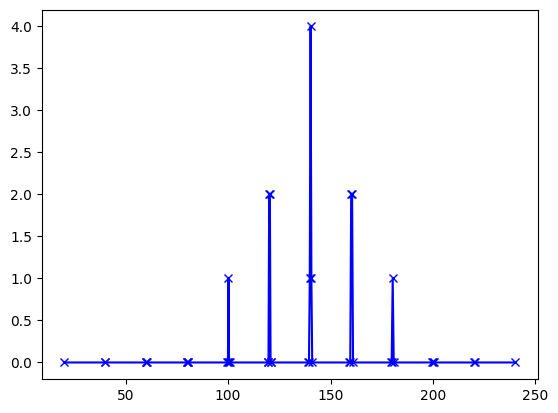

In [66]:
ax_array = [701,702,703,704,705,706]
ay_array = [0,1,2,1,0,0]
bx_array = [707,708,709,710,711,712,713]
by_array = [0,0,1,2,1,0,0]

res_ax_array = [1e7/ax for ax in ax_array]
res_bx_array = [1e7/bx for bx in bx_array]

sorted_x, sorted_y = convolve(res_bx_array, by_array, res_ax_array, ay_array, mode='subtract')
plt.plot(sorted_x, sorted_y, 'bx-')

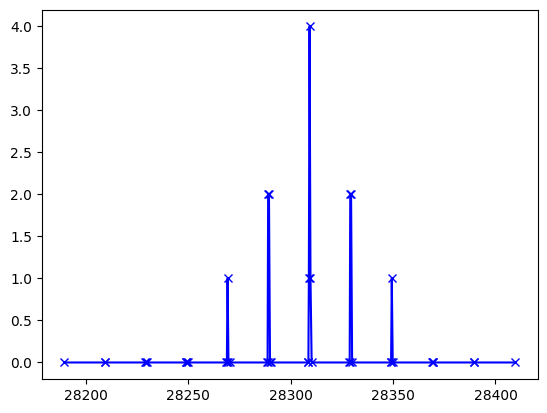

In [75]:
sorted_x, sorted_y = convolve(res_ax_array, ay_array, res_bx_array, by_array, mode='add')
plt.plot(sorted_x, sorted_y, 'bx-')